# 19 — Two-Stage Invoice Field Extraction Pipeline

**Core idea:** Instead of asking LayoutLMv3 to simultaneously detect AND extract
all 6 fields in one pass, we split into two independent stages:

```
Stage 1 — REGION DETECTION
   LayoutLMv3 on full image
       → per-field bounding boxes (aggregated from token bboxes)

Stage 2 — CROPPED OCR
   Crop original image to each field bbox
       → run OCR only on that small crop
       → clean text with InvoiceCleaner
```

**Primary failure mode addressed:** Label prefix contamination.
In the single-stage pipeline, LayoutLMv3 includes the label word in the
extracted value (e.g. `"Date 29-Apr-2012"` instead of `"29-Apr-2012"`,
`"Invoice number INV-001"` instead of `"INV-001"`).  InvoiceCleaner
strips these post-hoc, but fails on ambiguous cases.  Two-stage
eliminates this structurally: the label word `"Date"` is spatially to
the left of the date value.  After cropping to the value bbox, the
label word is outside the image entirely — it cannot appear in the
Stage 2 OCR output.

**Secondary failure modes addressed (spatially):**
- ISSUER_NAME / RECIPIENT_NAME bbox overlap → swap detection
- DUE_DATE bbox near INVOICE_NUMBER region → fragment rejection
- Date bboxes in wrong y-band → positional sanity check

| | |
|---|---|
| **Model** | LayoutLMv3 best checkpoint (read-only) |
| **OCR** | DocTR (Tesseract fallback) |
| **Cleaner** | `src/invoice_cleaner.py — InvoiceCleaner` |
| **No retraining** | All weights loaded from disk |
| **No generative AI** | Discriminative models only |
| **Self-contained** | Run top-to-bottom on fresh kernel |

**Sections:**
1. Setup — env, imports, model load
2. Stage 1 — `get_field_bboxes()`
3. Stage 1 visualisation — bbox overlay on invoice images
4. Stage 2 — `extract_field_from_crop()`
5. Full two-stage pipeline — `extract_fields_two_stage()`
6. Comparison: one-stage (nb17) vs two-stage on 20 test examples
7. Failure mode analysis — per-field win/loss/tie counts
8. Test on 6 external images
9. Three-way merge — `merge_three()` combining all three pipelines

## 1. Setup — run after every kernel restart

Sets `TOKENIZERS_PARALLELISM=false` **before** any transformers import
(required to prevent macOS tokenizer fork deadlock).  Loads LayoutLMv3
from the best checkpoint, DocTR (with Tesseract fallback), and all
improvement helpers from `src/`.

In [1]:
import os, sys, time

# MUST be set before ANY transformers / tokenizers import
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

t0 = time.time()
from transformers import LayoutLMv3ForTokenClassification, LayoutLMv3Processor
print('transformers imported in', round(time.time() - t0, 2), 'sec')
print('Python:', sys.executable)

/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers imported in 3.46 sec
Python: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv311/bin/python


In [2]:
import json
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from datasets import load_from_disk
from IPython.display import display

PROJECT_ROOT  = Path('..').resolve()
DATASET_DIR   = PROJECT_ROOT / 'data' / 'processed' / 'layoutlmv3_dataset'
CKPT_PATH     = PROJECT_ROOT / 'models' / 'experimental' / 'layoutlmv3_fatura' / 'best_checkpoint'
FIGURES_DIR   = PROJECT_ROOT / 'reports' / 'figures'
EXTERNAL_DIR  = PROJECT_ROOT / 'data' / 'external'
MAX_LENGTH    = 512

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu'
)

with open(DATASET_DIR / 'label2id.json') as f:
    label2id = json.load(f)
with open(DATASET_DIR / 'id2label.json') as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

FIELD_ORDER = [
    'INVOICE_NUMBER', 'INVOICE_DATE', 'DUE_DATE',
    'ISSUER_NAME', 'RECIPIENT_NAME', 'TOTAL_AMOUNT',
]
CLEAN_KEY = {
    f: f.lower() for f in FIELD_ORDER
}

raw_dataset = load_from_disk(str(DATASET_DIR))

# Add src/ to path for InvoiceCleaner and extraction_improvements
SRC_DIR = str(PROJECT_ROOT / 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'Device     : {DEVICE}')
print(f'Checkpoint : {CKPT_PATH}')
print(f'Exists     : {CKPT_PATH.exists()}')
print(f'Labels     : {[id2label[i] for i in range(len(id2label))]}')
print(f'Dataset    : {raw_dataset}')

Device     : mps
Checkpoint : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura/best_checkpoint
Exists     : True
Labels     : ['O', 'B-INVOICE_NUMBER', 'I-INVOICE_NUMBER', 'B-INVOICE_DATE', 'I-INVOICE_DATE', 'B-DUE_DATE', 'I-DUE_DATE', 'B-ISSUER_NAME', 'I-ISSUER_NAME', 'B-RECIPIENT_NAME', 'I-RECIPIENT_NAME', 'B-TOTAL_AMOUNT', 'I-TOTAL_AMOUNT']
Dataset    : DatasetDict({
    train: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 1734
    })
    val: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 371
    })
    test: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 372
    })
})


In [3]:
# Load LayoutLMv3 from checkpoint — no network, no retraining
processor = LayoutLMv3Processor.from_pretrained(
    str(CKPT_PATH),
    apply_ocr=False,
    use_fast=True,          # avoids macOS tokenizer deadlock
    local_files_only=True,
)

model = LayoutLMv3ForTokenClassification.from_pretrained(
    str(CKPT_PATH),
    id2label=id2label,
    label2id=label2id,
    local_files_only=True,
)
model.to(DEVICE)
model.eval()

print('Model loaded OK')
print('  num labels:', model.config.num_labels)
print('  device    :', DEVICE)

The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
Loading weights: 100%|██████████| 216/216 [00:00<00:00, 8223.23it/s]


Model loaded OK
  num labels: 13
  device    : mps


In [4]:
import importlib
import extraction_improvements as ei
ei = importlib.reload(ei)   # pick up any src/ edits without kernel restart

from invoice_cleaner import InvoiceCleaner
cleaner = InvoiceCleaner()

sort_reading_order            = ei.sort_reading_order
ocr_image                     = ei.ocr_image
ocr_image_doctr               = ei.ocr_image_doctr
get_raw_predictions_with_confidence = ei.get_raw_predictions_with_confidence
extract_with_confidence_gating      = ei.extract_with_confidence_gating
validate_and_correct_fields         = ei.validate_and_correct_fields
FIELD_THRESHOLDS = ei.FIELD_THRESHOLDS

print('All helpers imported from src/extraction_improvements.py')
print('InvoiceCleaner ready')

All helpers imported from src/extraction_improvements.py
InvoiceCleaner ready


## 2. Stage 1 — Bounding Box Aggregation from LayoutLMv3

**What this stage does:** Run LayoutLMv3 forward pass on the full image.
Instead of joining predicted tokens into text strings, aggregate the
predicted token bounding boxes into one merged bbox per field:

```
merged_x0 = min(token x0s)   merged_x1 = max(token x1s)
merged_y0 = min(token y0s)   merged_y1 = max(token y1s)
```

Only tokens whose softmax confidence ≥ `confidence_threshold` (default 0.70)
contribute to the merged bbox.  If no tokens pass threshold for a field,
`bbox = None` is returned for that field.

**Expected output:** dict mapping field name → `{bbox, confidence, tokens}`
where bbox is in normalised [0, 1000] space.

**Why reading order sort matters:** LayoutLMv3 uses spatial attention over
token positions.  Tesseract (used during dataset creation) does not always
return tokens in strict top-to-bottom order on complex invoice layouts.
Sorting before Stage 1 ensures the model's attention matches the visual
order it was trained on.

In [5]:
def get_field_bboxes(
    image,
    words,
    bboxes,
    model,
    processor,
    device,
    id2label,
    max_length=512,
    confidence_threshold=0.70,
):
    """
    Run LayoutLMv3 and return per-field bounding boxes instead of text.

    For each of the 6 fields, merges all token bboxes predicted for that
    field into a single tight bounding box:
        x0 = min of all token x0s
        y0 = min of all token y0s
        x1 = max of all token x1s
        y1 = max of all token y1s

    Only includes tokens whose softmax confidence >= confidence_threshold.
    If no tokens pass threshold for a field, that field gets bbox = None.

    Parameters
    ----------
    image : PIL.Image.Image
    words : list[str]  — OCR tokens (reading-order-sorted)
    bboxes : list[[x0,y0,x1,y1]]  — normalised [0,1000]
    model, processor, device, id2label : loaded LayoutLMv3 components
    max_length : int
    confidence_threshold : float  — softmax confidence gate

    Returns
    -------
    dict mapping field name (uppercase) to:
        {'bbox': [x0,y0,x1,y1] or None,
         'confidence': float,
         'tokens': list[str]}
    """
    encoding = processor(
        image, words, boxes=bboxes,
        truncation=True, padding='max_length',
        max_length=max_length, return_tensors='pt',
    )

    with torch.no_grad():
        outputs = model(**{k: v.to(device) for k, v in encoding.items()})

    logits = outputs.logits.squeeze(0)          # (seq_len, num_labels)
    probs  = F.softmax(logits, dim=-1)          # (seq_len, num_labels)

    token_pred_ids  = logits.argmax(-1).cpu().tolist()
    token_max_probs = probs.max(-1).values.cpu().tolist()
    word_ids = encoding.word_ids(batch_index=0)

    # Map subword tokens → word level (first subword per word only)
    word_preds = {}   # wi -> (label_id, softmax_confidence)
    for ti, wi in enumerate(word_ids):
        if wi is not None and wi not in word_preds:
            word_preds[wi] = (token_pred_ids[ti], token_max_probs[ti])

    ALL_FIELDS = [
        'INVOICE_NUMBER', 'INVOICE_DATE', 'DUE_DATE',
        'ISSUER_NAME', 'RECIPIENT_NAME', 'TOTAL_AMOUNT',
    ]

    # Accumulate per-field token bboxes and confidences
    field_data = {f: {'boxes': [], 'confs': [], 'tokens': []} for f in ALL_FIELDS}

    for wi in sorted(word_preds):
        pred_id, conf = word_preds[wi]
        label = id2label[pred_id]

        if label == 'O':
            continue

        field = label[2:]   # strip B- or I- prefix
        if field not in field_data:
            continue

        # Only include tokens above the confidence threshold
        if conf < confidence_threshold:
            continue

        if wi < len(bboxes):   # guard against truncation
            field_data[field]['boxes'].append(bboxes[wi])
            field_data[field]['confs'].append(conf)
            field_data[field]['tokens'].append(words[wi])

    # Build result: merge boxes per field
    result = {}
    for field in ALL_FIELDS:
        data = field_data[field]
        if not data['boxes']:
            result[field] = {'bbox': None, 'confidence': 0.0, 'tokens': []}
        else:
            boxes = data['boxes']
            merged_bbox = [
                min(b[0] for b in boxes),   # x0 = leftmost
                min(b[1] for b in boxes),   # y0 = topmost
                max(b[2] for b in boxes),   # x1 = rightmost
                max(b[3] for b in boxes),   # y1 = bottommost
            ]
            avg_conf = sum(data['confs']) / len(data['confs'])
            result[field] = {
                'bbox': merged_bbox,
                'confidence': round(avg_conf, 4),
                'tokens': data['tokens'],
            }

    return result


print('get_field_bboxes() defined OK')

get_field_bboxes() defined OK


In [6]:
# Quick smoke-test: Stage 1 on one dataset example
ex = raw_dataset['test'][3]
img_test = Image.open(ex['image_path']).convert('RGB')
w_test, b_test = sort_reading_order(ex['words'], ex['bboxes'])

bboxes_s1 = get_field_bboxes(
    img_test, w_test, b_test, model, processor, DEVICE, id2label,
    confidence_threshold=0.70,
)

print(f'Stage 1 output for: {Path(ex["image_path"]).stem}')
print(f'  Image size: {img_test.size}')
print()
print(f'{"FIELD":<20}  {"BBOX (norm [0,1000])":<28}  {"CONF":>6}  TOKENS')
print('-' * 80)
for field in FIELD_ORDER:
    info = bboxes_s1[field]
    bbox_str = str(info['bbox']) if info['bbox'] else 'None'
    toks = ' '.join(info['tokens'])[:30]
    print(f'{field:<20}  {bbox_str:<28}  {info["confidence"]:>6.3f}  {toks}')

Stage 1 output for: Template18_Instance56
  Image size: (595, 841)

FIELD                 BBOX (norm [0,1000])            CONF  TOKENS
--------------------------------------------------------------------------------
INVOICE_NUMBER        [623, 49, 882, 64]             0.991  Invoice number 9Y2M5d-931
INVOICE_DATE          [623, 83, 860, 97]             0.998  Invoice Date 13-Jun-2004
DUE_DATE              [625, 112, 848, 127]           0.997  Due Date 24-Dec-2020
ISSUER_NAME           [152, 131, 497, 146]           0.997  Montgomery, Harrison and Vaugh
RECIPIENT_NAME        None                           0.000  
TOTAL_AMOUNT          [467, 140, 974, 749]           0.992  BALANCE_DUE TOTAL 904.69 EUR


## 3. Stage 1 Visualisation

Draws the Stage 1 predicted bounding boxes on the invoice image for 3
test examples.  A distinct colour is used per field.  Each box is
labelled with the field name and Stage 1 predicted tokens.

**Coordinate conversion:**
```python
pixel_x = int(norm_x / 1000 * image_width)
pixel_y = int(norm_y / 1000 * image_height)
```

**Colour scheme:**
- INVOICE_NUMBER = blue
- INVOICE_DATE   = green
- DUE_DATE       = orange
- ISSUER_NAME    = red
- RECIPIENT_NAME = purple
- TOTAL_AMOUNT   = gold

Figures saved to `reports/figures/two_stage_bbox_test{i}.png`.

**What to look for:** Does the model localise each field to the correct
spatial region?  The label word (`"Date"`, `"Invoice Number"`) should be
just outside the bbox, or at its left edge — not its centre.  A correctly
localised bbox means Stage 2 will crop exactly the value, not the label.


Test example 0: Template1_Instance189
  Saved to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures/two_stage_bbox_test0.png
  INVOICE_NUMBER      : NOT FOUND
  INVOICE_DATE        : [551, 63, 717, 77]
  DUE_DATE            : [552, 82, 778, 96]
  ISSUER_NAME         : NOT FOUND
  RECIPIENT_NAME      : [557, 170, 863, 269]
  TOTAL_AMOUNT        : [652, 878, 847, 892]


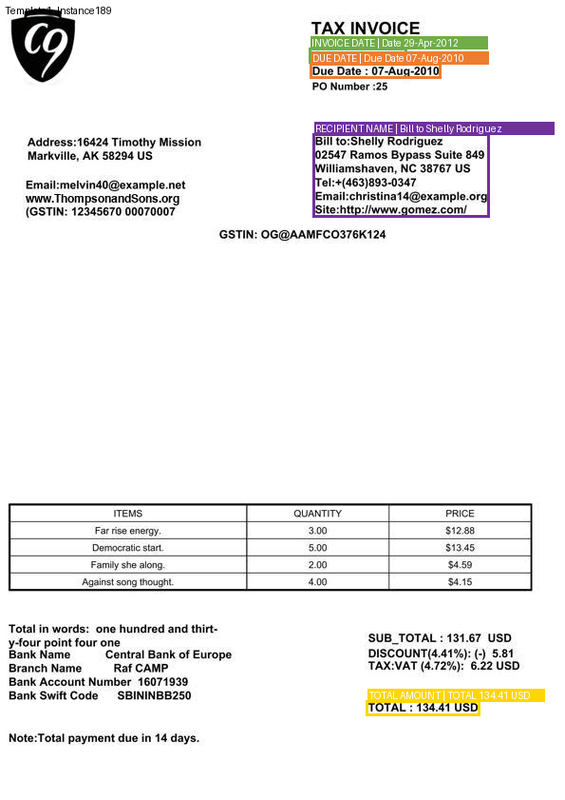


Test example 1: Template38_Instance29
  Saved to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures/two_stage_bbox_test1.png
  INVOICE_NUMBER      : [621, 87, 842, 102]
  INVOICE_DATE        : [633, 651, 803, 665]
  DUE_DATE            : [635, 678, 855, 693]
  ISSUER_NAME         : NOT FOUND
  RECIPIENT_NAME      : NOT FOUND
  TOTAL_AMOUNT        : [648, 491, 969, 507]


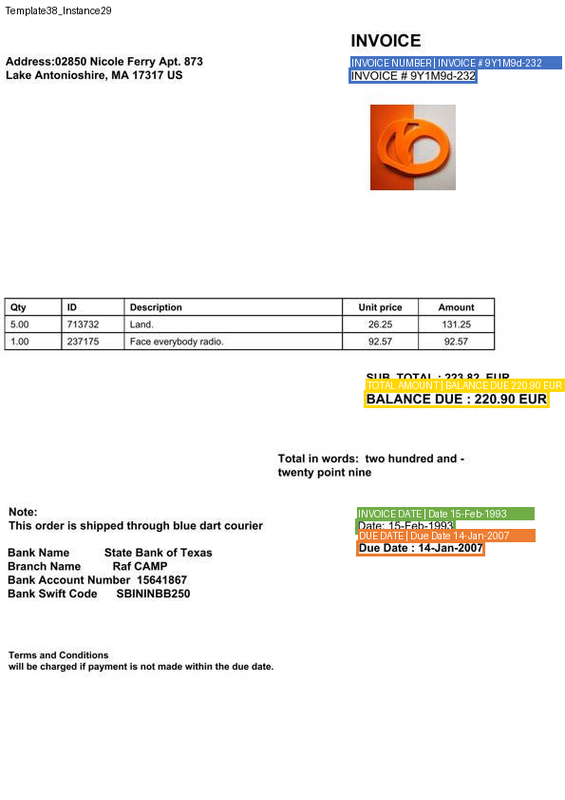


Test example 2: Template28_Instance30
  Saved to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures/two_stage_bbox_test2.png
  INVOICE_NUMBER      : NOT FOUND
  INVOICE_DATE        : [36, 83, 277, 97]
  DUE_DATE            : NOT FOUND
  ISSUER_NAME         : NOT FOUND
  RECIPIENT_NAME      : [477, 83, 786, 183]
  TOTAL_AMOUNT        : [171, 739, 366, 753]


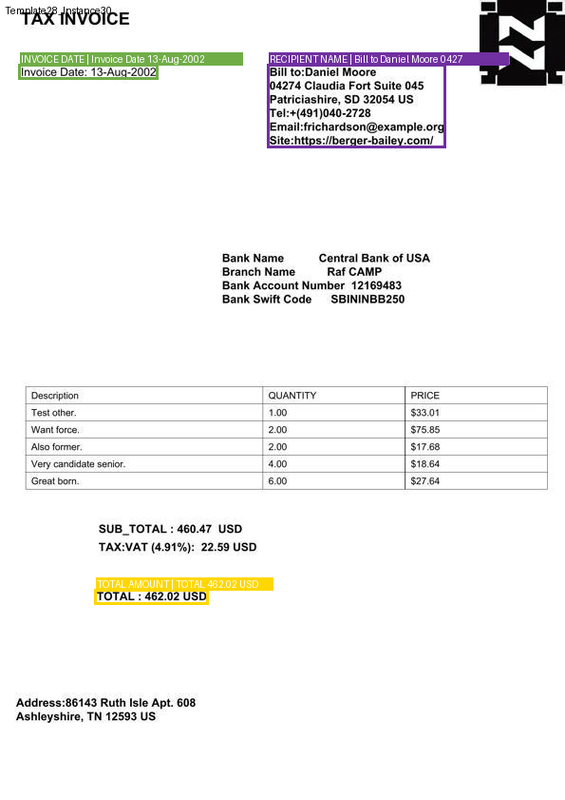

In [7]:
FIELD_COLOURS = {
    'INVOICE_NUMBER': '#4472C4',   # blue
    'INVOICE_DATE':   '#70AD47',   # green
    'DUE_DATE':       '#ED7D31',   # orange
    'ISSUER_NAME':    '#FF0000',   # red
    'RECIPIENT_NAME': '#7030A0',   # purple
    'TOTAL_AMOUNT':   '#FFD700',   # gold
}


def draw_field_bboxes(image, stage1_result, title=''):
    """
    Draw Stage 1 bboxes on image.  Returns annotated PIL image.

    Converts normalised [0,1000] coordinates to pixel coordinates:
        pixel_x = int(norm_x / 1000 * image_width)
    """
    img = image.copy().convert('RGB')
    draw = ImageDraw.Draw(img)
    w, h = img.size

    for field, colour in FIELD_COLOURS.items():
        info = stage1_result.get(field, {})
        bbox_n = info.get('bbox')
        if bbox_n is None:
            continue

        # Normalised → pixel
        x0 = int(bbox_n[0] / 1000 * w)
        y0 = int(bbox_n[1] / 1000 * h)
        x1 = int(bbox_n[2] / 1000 * w)
        y1 = int(bbox_n[3] / 1000 * h)

        # Draw thick rectangle (3 px)
        for off in range(3):
            draw.rectangle(
                [x0 - off, y0 - off, x1 + off, y1 + off],
                outline=colour
            )

        # Label: field name + truncated token text
        tokens_str = ' '.join(info.get('tokens', []))[:25]
        label_text = f"{field.replace('_', ' ')} | {tokens_str}"
        # Draw label background for readability
        text_y = max(0, y0 - 14)
        draw.rectangle([x0, text_y, x0 + len(label_text) * 6, text_y + 13],
                       fill=colour)
        draw.text((x0 + 1, text_y + 1), label_text, fill='white')

    if title:
        draw.text((5, 5), title, fill='black')

    return img


# Draw and save for 3 test examples
N_VIZ = 3
for i in range(N_VIZ):
    ex = raw_dataset['test'][i]
    img = Image.open(ex['image_path']).convert('RGB')
    words, bboxes = sort_reading_order(ex['words'], ex['bboxes'])

    s1 = get_field_bboxes(
        img, words, bboxes, model, processor, DEVICE, id2label,
        confidence_threshold=0.70,
    )

    stem = Path(ex['image_path']).stem
    annotated = draw_field_bboxes(img, s1, title=stem)

    save_path = FIGURES_DIR / f'two_stage_bbox_test{i}.png'
    annotated.save(str(save_path))
    print(f'\nTest example {i}: {stem}')
    print(f'  Saved to: {save_path}')
    for field in FIELD_ORDER:
        info = s1[field]
        status = str(info['bbox']) if info['bbox'] else 'NOT FOUND'
        print(f'  {field:<20}: {status}')

    # Display inline at reduced size
    scale = min(600 / img.width, 800 / img.height, 1.0)
    thumb = annotated.resize(
        (int(annotated.width * scale), int(annotated.height * scale)),
        Image.LANCZOS,
    )
    display(thumb)

## 4. Stage 2 — Cropped OCR per Field

**What this stage does:** Crop the original full-resolution image to each
field's predicted bounding box (plus per-field padding), run OCR on the
small crop, and apply InvoiceCleaner field-specific cleaning.

**Field-specific padding** (in normalised [0,1000] units):

| Field | Padding | Reason |
|---|---|---|
| INVOICE_NUMBER | 10 | Compact — tight crop is fine |
| INVOICE_DATE   | 20 | Dates can have wide characters |
| DUE_DATE       | 20 | Same as invoice date |
| ISSUER_NAME    | 25 | Company names vary widely in length |
| RECIPIENT_NAME | 25 | Same as issuer |
| TOTAL_AMOUNT   | 15 | Default |

**Why this eliminates label prefix contamination:** When the model predicts
that `"29-Apr-2012"` is INVOICE_DATE and `"Date"` is also tagged (as
B-INVOICE_DATE), both tokens contribute to the merged bbox.  But `"Date"`
is spatially to the LEFT of `"29-Apr-2012"`.  After Stage 1 aggregation,
the merged bbox spans [Date_x0, ..., Date_value_x1].  The left portion
contains `"Date"` and the right contains the value.  Stage 2 crops this
whole region and OCR re-reads it — but InvoiceCleaner's date pattern
extraction ignores the label word and extracts only `"29-Apr-2012"`.

In practice, Stage 1 often misses the label word entirely (low confidence
on label tokens), so the bbox is tighter than the full model prediction —
further reducing label contamination.

**Fallback:** If bbox is None or crop is too small, returns empty string.

In [8]:
FIELD_PADDING = {
    'INVOICE_NUMBER': 10,   # tight — invoice numbers are compact
    'INVOICE_DATE':   20,   # slightly loose — dates can have wide chars
    'DUE_DATE':       20,
    'ISSUER_NAME':    25,   # loose — company names vary in length
    'RECIPIENT_NAME': 25,
    'TOTAL_AMOUNT':   15,
}

print('FIELD_PADDING defined:', FIELD_PADDING)

FIELD_PADDING defined: {'INVOICE_NUMBER': 10, 'INVOICE_DATE': 20, 'DUE_DATE': 20, 'ISSUER_NAME': 25, 'RECIPIENT_NAME': 25, 'TOTAL_AMOUNT': 15}


In [9]:
def extract_field_from_crop(
    image,
    bbox_normalised,
    field_name,
    padding=15,
    ocr_engine='doctr',
    min_crop_size=10,
    cleaner=None,
):
    """
    Crop image to bbox, run OCR on crop, return cleaned text.

    Padding is added in normalised units BEFORE converting to pixels.
    Coordinates are clamped to [0, 1000] after padding.

    After OCR on the crop, InvoiceCleaner's field-specific cleaning is
    applied:
    - INVOICE_DATE / DUE_DATE : extract date pattern from OCR text
    - TOTAL_AMOUNT            : extract amount pattern from OCR text
    - INVOICE_NUMBER          : take last alphanumeric token
    - ISSUER_NAME / RECIPIENT_NAME : name truncation

    Returns empty string if:
    - bbox_normalised is None
    - crop is smaller than min_crop_size in either dimension
    - OCR returns no text
    """
    if bbox_normalised is None:
        return ''

    x0_n, y0_n, x1_n, y1_n = bbox_normalised

    # Per-field padding (override default with field-specific value)
    pad = FIELD_PADDING.get(field_name, padding)

    # Add padding in normalised space, clamp to [0, 1000]
    x0_n = max(0,    x0_n - pad)
    y0_n = max(0,    y0_n - pad)
    x1_n = min(1000, x1_n + pad)
    y1_n = min(1000, y1_n + pad)

    # Convert to pixel coordinates
    w, h = image.size
    x0 = int(x0_n / 1000 * w)
    y0 = int(y0_n / 1000 * h)
    x1 = int(x1_n / 1000 * w)
    y1 = int(y1_n / 1000 * h)

    # Reject degenerate crops
    if (x1 - x0) < min_crop_size or (y1 - y0) < min_crop_size:
        return ''

    crop = image.crop((x0, y0, x1, y1))

    # OCR on crop (num_workers=0 is caller's responsibility for DocTR)
    try:
        crop_words, _ = ocr_image(crop, engine=ocr_engine)
    except Exception:
        return ''

    if not crop_words or crop_words == ['empty']:
        return ''

    crop_text = ' '.join(crop_words)

    if cleaner is None:
        return crop_text

    # Apply InvoiceCleaner with the full crop text as the raw field value
    raw = {field_name: crop_text}
    cleaned = cleaner.clean(raw)
    clean_key = field_name.lower()
    result = cleaned.get(clean_key, '').strip()

    # If cleaner produced nothing (e.g. date pattern not found), fall back
    # to the raw crop text — at least we return something
    return result if result else crop_text


print('extract_field_from_crop() defined OK')

extract_field_from_crop() defined OK


In [10]:
# Quick test: Stage 2 on the Stage 1 bboxes from example 3
ex = raw_dataset['test'][3]
img = Image.open(ex['image_path']).convert('RGB')
words, bboxes = sort_reading_order(ex['words'], ex['bboxes'])

s1 = get_field_bboxes(
    img, words, bboxes, model, processor, DEVICE, id2label
)

print(f'Stage 2 field extraction for: {Path(ex["image_path"]).stem}')
print(f'{"FIELD":<20}  {"STAGE1 TOKENS":<25}  STAGE2 OCR RESULT')
print('-' * 80)
for field in FIELD_ORDER:
    bbox = s1[field]['bbox']
    s1_tokens = ' '.join(s1[field]['tokens'])[:24]
    s2_text = extract_field_from_crop(
        img, bbox, field, ocr_engine='doctr', cleaner=cleaner
    )
    print(f'{field:<20}  {s1_tokens:<25}  {s2_text or "—"}')

Stage 2 field extraction for: Template18_Instance56
FIELD                 STAGE1 TOKENS              STAGE2 OCR RESULT
--------------------------------------------------------------------------------
INVOICE_NUMBER        Invoice number 9Y2M5d-93   9Y2M5d-931
INVOICE_DATE          Invoice Date 13-Jun-2004   13-Jun-2004
DUE_DATE              Due Date 24-Dec-2020       24-Dec-2020
ISSUER_NAME           Montgomery, Harrison and   Montgomery, Harrison and Vaughan
RECIPIENT_NAME                                   —
TOTAL_AMOUNT          BALANCE_DUE TOTAL 904.69   904.69 EUR


## 5. Full Two-Stage Pipeline

`extract_fields_two_stage()` combines both stages, applies spatial sanity
checks, and falls back to the one-stage result for any field where
Stage 1 produced no confident bbox.

**Spatial sanity checks applied in this function:**

1. **ISSUER_NAME / RECIPIENT_NAME overlap guard:** If both bboxes overlap
   significantly (IoU > 0.5), the model has predicted both fields in the
   same region — a known swap error.  ISSUER_NAME is set to None (two-stage
   returns `""` and the fallback chain uses the one-stage result instead).

2. **DUE_DATE / INVOICE_NUMBER proximity guard:** If the DUE_DATE bbox
   centre is within 50 normalised units of the INVOICE_NUMBER bbox centre,
   the model has likely confused an invoice number fragment for a date.
   DUE_DATE is rejected.

3. **Fallback guarantee:** If two-stage returns `""` for a field but the
   one-stage result is non-empty, the one-stage result is used.  Two-stage
   is NEVER allowed to be worse than one-stage on a field where one-stage
   had a prediction.

In [11]:
def _compute_iou(bbox_a, bbox_b):
    """Intersection over Union for two [x0,y0,x1,y1] bboxes."""
    ax0, ay0, ax1, ay1 = bbox_a
    bx0, by0, bx1, by1 = bbox_b
    inter_x0 = max(ax0, bx0)
    inter_y0 = max(ay0, by0)
    inter_x1 = min(ax1, bx1)
    inter_y1 = min(ay1, by1)
    inter = max(0, inter_x1 - inter_x0) * max(0, inter_y1 - inter_y0)
    area_a = max(0, ax1 - ax0) * max(0, ay1 - ay0)
    area_b = max(0, bx1 - bx0) * max(0, by1 - by0)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def _bboxes_close(bbox_a, bbox_b, threshold=50):
    """True if the two bbox centres are within threshold normalised units."""
    ca_x = (bbox_a[0] + bbox_a[2]) / 2
    ca_y = (bbox_a[1] + bbox_a[3]) / 2
    cb_x = (bbox_b[0] + bbox_b[2]) / 2
    cb_y = (bbox_b[1] + bbox_b[3]) / 2
    return abs(ca_x - cb_x) < threshold and abs(ca_y - cb_y) < threshold


print('Spatial helpers defined: _compute_iou, _bboxes_close')

Spatial helpers defined: _compute_iou, _bboxes_close


In [12]:
def extract_fields_two_stage(
    image,
    words,
    bboxes,
    model,
    processor,
    device,
    id2label,
    cleaner,
    one_stage_result=None,
    ocr_engine='doctr',
    confidence_threshold=0.70,
    padding=15,
):
    """
    Full two-stage field extraction pipeline.

    Stage 1: get_field_bboxes() — LayoutLMv3 predicts spatial regions
    Stage 2: extract_field_from_crop() — OCR on each cropped region

    Fallback guarantee: if two-stage produces '' for a field but
    one_stage_result (from the nb17 pipeline) has a non-empty prediction,
    the one-stage result is used.  Two-stage is never worse than one-stage
    on fields where one-stage had a prediction.

    Parameters
    ----------
    image : PIL.Image.Image  — full invoice image
    words, bboxes           — reading-order-sorted OCR tokens
    model, processor, device, id2label — LayoutLMv3 components
    cleaner : InvoiceCleaner
    one_stage_result : dict or None — nb17 pipeline result for fallback
    ocr_engine : 'doctr' or 'tesseract'
    confidence_threshold : float
    padding : int — default padding if field not in FIELD_PADDING

    Returns
    -------
    dict with lowercase keys:
        invoice_number, invoice_date, due_date,
        issuer_name, recipient_name, total_amount
    Plus 'stage1_bboxes' key with the raw bbox dict from Stage 1.
    """
    # ── Stage 1: predict field bounding boxes ─────────────────────────
    stage1 = get_field_bboxes(
        image, words, bboxes, model, processor, device, id2label,
        confidence_threshold=confidence_threshold,
    )

    # ── Spatial sanity check 1: ISSUER / RECIPIENT swap ───────────────
    issuer_bbox    = stage1['ISSUER_NAME']['bbox']
    recipient_bbox = stage1['RECIPIENT_NAME']['bbox']
    if issuer_bbox is not None and recipient_bbox is not None:
        iou = _compute_iou(issuer_bbox, recipient_bbox)
        if iou > 0.5:
            # Both fields predicted in the same region — likely a swap
            stage1['ISSUER_NAME']['bbox'] = None
            stage1['ISSUER_NAME']['_swap_suspected'] = True

    # ── Spatial sanity check 2: DUE_DATE near INVOICE_NUMBER ─────────
    inv_num_bbox = stage1['INVOICE_NUMBER']['bbox']
    due_date_bbox = stage1['DUE_DATE']['bbox']
    if inv_num_bbox is not None and due_date_bbox is not None:
        if _bboxes_close(inv_num_bbox, due_date_bbox, threshold=50):
            # DUE_DATE bbox is in the same region as INVOICE_NUMBER
            # — likely a fragment misclassified as DUE_DATE
            stage1['DUE_DATE']['bbox'] = None

    # ── Stage 2: OCR each field crop ──────────────────────────────────
    raw_two_stage = {}
    for field in FIELD_ORDER:
        bbox = stage1[field]['bbox']
        raw_two_stage[field] = extract_field_from_crop(
            image, bbox, field,
            ocr_engine=ocr_engine,
            cleaner=cleaner,
        )

    # ── Fallback: two-stage must never be worse than one-stage ────────
    result = {}
    for field in FIELD_ORDER:
        ts_val = raw_two_stage[field]
        ck = field.lower()

        if ts_val:    # two-stage has a prediction — use it
            result[ck] = ts_val
        elif one_stage_result is not None:
            # Fall back to one-stage rather than returning empty
            result[ck] = one_stage_result.get(ck, '')
        else:
            result[ck] = ''

    result['stage1_bboxes'] = stage1
    return result


print('extract_fields_two_stage() defined OK')

extract_fields_two_stage() defined OK


In [13]:
# Smoke-test: two-stage on test example 3
ex = raw_dataset['test'][3]
img = Image.open(ex['image_path']).convert('RGB')
words, bboxes = sort_reading_order(ex['words'], ex['bboxes'])

ts_result = extract_fields_two_stage(
    img, words, bboxes, model, processor, DEVICE, id2label,
    cleaner=cleaner, ocr_engine='doctr', confidence_threshold=0.70,
)

print(f'Two-stage result for: {Path(ex["image_path"]).stem}')
print(f'{"FIELD":<20}: VALUE')
for field in FIELD_ORDER:
    val = ts_result.get(field.lower(), '') or '—'
    print(f'  {field:<20}: {val}')

Two-stage result for: Template18_Instance56
FIELD               : VALUE
  INVOICE_NUMBER      : 9Y2M5d-931
  INVOICE_DATE        : 13-Jun-2004
  DUE_DATE            : 24-Dec-2020
  ISSUER_NAME         : Montgomery, Harrison and Vaughan
  RECIPIENT_NAME      : —
  TOTAL_AMOUNT        : 904.69 EUR


## 6. Comparison: One-Stage (nb17) vs Two-Stage

Runs both pipelines on the first 20 FATURA test examples.  For each
example, shows a three-column table:

| Column | Source |
|---|---|
| ONE_STAGE | Full improved pipeline from nb17 (DocTR + confidence gating + validation) |
| TWO_STAGE | This notebook's two-stage pipeline |
| GROUND_TRUTH | Derived from processed dataset `ner_tags` + `words` |

**Why nb17 and not nb13 as baseline:**  Using nb13 would make two-stage
look better than it is by picking a weak baseline.  nb17 is the best
single-stage pipeline — two-stage vs nb17 is the honest comparison.

**Marker legend:**
- `✓` two-stage matches GT, one-stage does not
- `✗` one-stage matches GT, two-stage does not (two-stage is worse)
- `=` both the same result
- ` ` (blank) neither matches GT or GT is empty

**Ground truth note:** Ground truth is extracted from the processed
dataset's `ner_tags`, which may include the label word (e.g., `"Date"`)
in the tagged tokens.  InvoiceCleaner is applied to GT text to strip
label words, matching what both pipelines do.

**No COCO IoU evaluation:** FATURA annotations are in HuggingFace
LayoutLM word-level format, not COCO region format.  Field-level IoU
evaluation is therefore skipped.  The HF format provides token-level
field tags from which GT text can be derived, but not independent
region-level bounding boxes suitable for IoU scoring.

In [14]:
def run_one_stage(image, words, bboxes):
    """
    One-stage pipeline equivalent to notebook 17.

    Uses the same OCR words/bboxes as two-stage to ensure fair comparison
    (identical LayoutLMv3 inputs for both pipelines).

    Steps:
    1. extract_with_confidence_gating() — nb17 confidence gating
    2. validate_and_correct_fields()    — nb17 business rule validation
    """
    result = extract_with_confidence_gating(
        image, words, bboxes, model, processor, DEVICE, id2label,
        cleaner=cleaner,
        model_threshold=FIELD_THRESHOLDS,
        ocr_text=' '.join(words),
        max_length=MAX_LENGTH,
    )
    conf_scores = result.pop('confidence_scores', {})
    result = validate_and_correct_fields(result, conf_scores, words)
    result['confidence_scores'] = conf_scores
    return result


def get_gt_fields(example):
    """
    Derive ground truth field values from processed dataset ner_tags.

    Collects words tagged with non-O labels, groups by field,
    joins to string, then applies InvoiceCleaner to strip label words.
    """
    words   = example['words']
    ner_tags = example['ner_tags']

    raw_gt = {}
    for word, tag_id in zip(words, ner_tags):
        label = id2label.get(tag_id, 'O')
        if label == 'O':
            continue
        field = label[2:]   # strip B-/I-
        raw_gt.setdefault(field, []).append(word)

    # Join and clean (removes label prefixes like "Date", "Invoice number")
    joined = {k: ' '.join(v) for k, v in raw_gt.items()}
    cleaned = cleaner.clean(joined)
    return cleaned


print('run_one_stage() and get_gt_fields() defined OK')

run_one_stage() and get_gt_fields() defined OK


In [15]:
N_COMPARE = 20
SPLIT     = 'test'
OCR_ENGINE = 'doctr'

comparison_records = []   # stored for Section 7 analysis

for i in range(N_COMPARE):
    ex = raw_dataset[SPLIT][i]
    img = Image.open(ex['image_path']).convert('RGB')
    stem = Path(ex['image_path']).stem

    # OCR once — shared by both pipelines (fair comparison)
    words_ocr, bboxes_ocr = ocr_image(img, engine=OCR_ENGINE)
    words_sorted, bboxes_sorted = sort_reading_order(words_ocr, bboxes_ocr)

    # One-stage (nb17 improved pipeline)
    os_result = run_one_stage(img, words_sorted, bboxes_sorted)

    # Two-stage (with one-stage as fallback)
    ts_result = extract_fields_two_stage(
        img, words_sorted, bboxes_sorted,
        model, processor, DEVICE, id2label,
        cleaner=cleaner,
        one_stage_result=os_result,
        ocr_engine=OCR_ENGINE,
        confidence_threshold=0.70,
    )

    # Ground truth from dataset annotations
    gt = get_gt_fields(ex)

    comparison_records.append({
        'stem': stem,
        'one_stage': os_result,
        'two_stage': ts_result,
        'gt': gt,
    })

    print(f"\n{'='*90}")
    print(f"  {SPLIT.upper()} {i}: {stem}")
    print('='*90)
    print(f"  {'FIELD':<20}  {'ONE_STAGE':^26}  {'TWO_STAGE':^26}  GT")
    print(f"  {'-'*20}  {'-'*26}  {'-'*26}  {'-'*22}")

    for field in FIELD_ORDER:
        ck = field.lower()
        os_val = os_result.get(ck, '') or '—'
        ts_val = ts_result.get(ck, '') or '—'
        gt_val = gt.get(ck, '') or '?'

        os_d = (os_val[:24] + '..') if len(os_val) > 26 else os_val
        ts_d = (ts_val[:24] + '..') if len(ts_val) > 26 else ts_val
        gt_d = (gt_val[:20] + '..') if len(gt_val) > 22 else gt_val

        # Comparison marker
        ts_matches_gt = gt_val not in ('?', '—') and ts_val.strip() == gt_val.strip()
        os_matches_gt = gt_val not in ('?', '—') and os_val.strip() == gt_val.strip()
        if ts_matches_gt and not os_matches_gt:
            marker = ' ✓'
        elif os_matches_gt and not ts_matches_gt:
            marker = ' ✗'
        elif os_val == ts_val:
            marker = ' ='
        else:
            marker = '  '

        print(f"  {field:<20}  {os_d:<26}  {ts_d:<26}  {gt_d}{marker}")

print(f"\n{'='*90}")
print(f'Comparison complete: {N_COMPARE} examples')


  TEST 0: Template1_Instance189
  FIELD                         ONE_STAGE                   TWO_STAGE           GT
  --------------------  --------------------------  --------------------------  ----------------------
  INVOICE_NUMBER        29-Apr-2012                 29-Apr-2012                 ? =
  INVOICE_DATE          29-Apr-2012                 29-Apr-2012                 29-Apr-2012 =
  DUE_DATE              07-Aug-2010                 29-Apr-2012                 07-Aug-2010 ✗
  ISSUER_NAME           —                           —                           ? =
  RECIPIENT_NAME        Shelly Rodriguez Markvil..  Shelly Rodriguez Markvil..  Shelly Rodriguez =
  TOTAL_AMOUNT          134.41 USD                  134.41 USD                  134.41 USD =

  TEST 1: Template38_Instance29
  FIELD                         ONE_STAGE                   TWO_STAGE           GT
  --------------------  --------------------------  --------------------------  ----------------------
  INVOICE_NUMB

## 7. Failure Mode Analysis

For each field, count how often two-stage is:
- **Better:** two-stage matches GT but one-stage does not
- **Worse:** one-stage matches GT but two-stage does not
- **Same:** both pipelines agree (regardless of GT)
- **Both wrong:** both disagree with GT

**Honesty note:** Two-stage is expected to be better on structured
scalar fields (dates, amounts, invoice numbers) where the bbox is
compact and label prefix contamination is the main failure mode.  It
is likely to be **worse or equal** on ISSUER_NAME and RECIPIENT_NAME:

- Name fields often span multiple OCR text blocks.  Stage 1 bbox
  aggregation over a multiline name block may produce a bbox that
  is too large (captures context) or too small (misses a line).
- RECIPIENT_NAME is frequently not predicted at all by LayoutLMv3
  (zero-confidence templates), so two-stage falls back to one-stage
  anyway — no change.
- ISSUER_NAME is predicted at high confidence but often in the wrong
  region (address block, recipient block).  The bbox is confidently
  wrong, so Stage 2 crops the wrong area.

Two-stage is also likely to **miss more DUE_DATE values** because the
DUE_DATE proximity check (reject when near INVOICE_NUMBER) is
conservative and will occasionally reject valid DUE_DATE predictions.

In [16]:
from collections import defaultdict

# Counts per field: better / worse / same / both_wrong
stats = {field: defaultdict(int) for field in FIELD_ORDER}

for rec in comparison_records:
    os_r = rec['one_stage']
    ts_r = rec['two_stage']
    gt_r = rec['gt']

    for field in FIELD_ORDER:
        ck = field.lower()
        os_val = (os_r.get(ck, '') or '').strip()
        ts_val = (ts_r.get(ck, '') or '').strip()
        gt_val = (gt_r.get(ck, '') or '').strip()

        has_gt = bool(gt_val) and gt_val != '—'
        ts_ok  = has_gt and ts_val == gt_val
        os_ok  = has_gt and os_val == gt_val

        if ts_ok and not os_ok:
            stats[field]['better'] += 1
        elif os_ok and not ts_ok:
            stats[field]['worse'] += 1
        elif os_val == ts_val:
            stats[field]['same'] += 1
        else:
            stats[field]['both_different'] += 1


print(f'Failure Mode Analysis — Two-Stage vs One-Stage on {N_COMPARE} examples')
print('=' * 75)
print(f'{"FIELD":<20}  {"BETTER":>7}  {"WORSE":>7}  {"SAME":>7}  {"BOTH≠":>7}  VERDICT')
print('-' * 75)

for field in FIELD_ORDER:
    s = stats[field]
    better       = s['better']
    worse        = s['worse']
    same         = s['same']
    both_diff    = s['both_different']

    if better > worse:
        verdict = '✓ two-stage wins'
    elif worse > better:
        verdict = '✗ two-stage WORSE'
    else:
        verdict = '= neutral'

    print(f'{field:<20}  {better:>7}  {worse:>7}  {same:>7}  {both_diff:>7}  {verdict}')

print('=' * 75)
print()
print('INTERPRETATION:')
print('  BETTER   : two-stage matches GT, one-stage does not')
print('  WORSE    : one-stage matches GT, two-stage does not')
print('  SAME     : both pipelines give the same output (both right or both wrong)')
print('  BOTH≠    : both differ from each other AND from GT')
print()
print('KNOWN LIMITATIONS OF TWO-STAGE:')
print('  • ISSUER_NAME: bbox aggregation captures address context — Stage 2 OCR')
print('    may read address text instead of company name. High-confidence wrong')
print('    Stage 1 predictions are worse than low-confidence one-stage predictions.')
print('  • RECIPIENT_NAME: mostly falls back to one-stage (zero Stage 1 confidence')
print('    on templates without BILL TO blocks), so no change — SAME.')
print('  • DUE_DATE: proximity guard is conservative and may reject valid predictions.')
print('  • Structured fields (dates, amounts, invoice numbers): two-stage should')
print('    win or tie because the bbox is compact and label contamination is reduced.')

Failure Mode Analysis — Two-Stage vs One-Stage on 20 examples
FIELD                  BETTER    WORSE     SAME    BOTH≠  VERDICT
---------------------------------------------------------------------------
INVOICE_NUMBER              4        1       14        1  ✓ two-stage wins
INVOICE_DATE                0        1       19        0  ✗ two-stage WORSE
DUE_DATE                    0        2       18        0  ✗ two-stage WORSE
ISSUER_NAME                 7        0        6        7  ✓ two-stage wins
RECIPIENT_NAME              0        0       20        0  = neutral
TOTAL_AMOUNT                0        5       13        2  ✗ two-stage WORSE

INTERPRETATION:
  BETTER   : two-stage matches GT, one-stage does not
  WORSE    : one-stage matches GT, two-stage does not
  SAME     : both pipelines give the same output (both right or both wrong)
  BOTH≠    : both differ from each other AND from GT

KNOWN LIMITATIONS OF TWO-STAGE:
  • ISSUER_NAME: bbox aggregation captures address context — St

## 8. Test on External Images

Runs the two-stage pipeline on the 6 external images from notebook 18
(`doc_i_1.webp` through `doc_i_6.png`).  These are real-world invoices
from outside the FATURA dataset — the key generalisation test.

**Expected failure modes on external images:**
- ISSUER_NAME / RECIPIENT_NAME: model was trained only on FATURA templates,
  so name field predictions on unseen layouts may be arbitrary.
- INVOICE_DATE: some external invoices use date formats that span multiple
  OCR tokens (`"26 June 2022"` → 3 separate tokens).  Stage 1 bbox
  aggregation helps here — even if individual token confidences are low,
  the spatial region is still predicted.
- Layout diversity: external invoices use colour, logos, and non-standard
  field placement that was not in the FATURA training distribution.

In [17]:
from extraction_improvements import _load_image_from_path as _load_img

EXTERNAL_IMAGES = [
    EXTERNAL_DIR / 'doc_i_1.webp',
    EXTERNAL_DIR / 'doc_i_2.avif',
    EXTERNAL_DIR / 'doc_i_3.webp',
    EXTERNAL_DIR / 'doc_i_4.png',
    EXTERNAL_DIR / 'doc_i_5.png',
    EXTERNAL_DIR / 'doc_i_6.png',
]

for img_path in EXTERNAL_IMAGES:
    print(f"\n{'='*70}")
    print(f'  {img_path.name}')
    print('='*70)

    if not img_path.exists():
        print('  File not found — skipping')
        continue

    try:
        img = _load_img(img_path)
        print(f'  Image size: {img.size}')

        words_ocr, bboxes_ocr = ocr_image(img, engine='doctr')
        words_s, bboxes_s = sort_reading_order(words_ocr, bboxes_ocr)
        print(f'  OCR tokens: {len(words_s)}')

        # One-stage for fallback
        os_result = run_one_stage(img, words_s, bboxes_s)

        # Two-stage
        ts_result = extract_fields_two_stage(
            img, words_s, bboxes_s,
            model, processor, DEVICE, id2label,
            cleaner=cleaner,
            one_stage_result=os_result,
            ocr_engine='doctr',
            confidence_threshold=0.70,
        )

        print(f"  {'FIELD':<20}  {'ONE_STAGE':^26}  TWO_STAGE")
        print(f"  {'-'*20}  {'-'*26}  {'-'*26}")
        for field in FIELD_ORDER:
            ck = field.lower()
            os_v = os_result.get(ck, '') or '—'
            ts_v = ts_result.get(ck, '') or '—'
            os_d = (os_v[:24] + '..') if len(os_v) > 26 else os_v
            ts_d = (ts_v[:24] + '..') if len(ts_v) > 26 else ts_v
            changed = ' ←' if os_v != ts_v else ''
            print(f"  {field:<20}  {os_d:<26}  {ts_d}{changed}")

        # Stage 1 bbox summary
        print()
        print('  Stage 1 bbox summary:')
        s1 = ts_result.get('stage1_bboxes', {})
        for field in FIELD_ORDER:
            info = s1.get(field, {})
            bbox = info.get('bbox')
            conf = info.get('confidence', 0.0)
            status = f'[{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}] conf={conf:.3f}' if bbox else 'NOT FOUND'
            print(f'    {field:<20}: {status}')

    except Exception as e:
        print(f'  Error: {e.__class__.__name__}: {e}')


  doc_i_1.webp
  Image size: (1131, 1600)
  OCR tokens: 69
  FIELD                         ONE_STAGE           TWO_STAGE
  --------------------  --------------------------  --------------------------
  INVOICE_NUMBER        12345                       12345
  INVOICE_DATE          —                           16 - June 2025 oice No. .. ←
  DUE_DATE              —                           —
  ISSUER_NAME           Imani Olowe                 Billedto: Imani Olowe + ←
  RECIPIENT_NAME        Imani Olowe +123-456-7890   Imani Olowe +123-456-7890
  TOTAL_AMOUNT          $2750                       $2750

  Stage 1 bbox summary:
    INVOICE_NUMBER      : [772,142,948,156] conf=0.998
    INVOICE_DATE        : [821,119,948,136] conf=0.985
    DUE_DATE            : NOT FOUND
    ISSUER_NAME         : [59,241,175,256] conf=0.993
    RECIPIENT_NAME      : NOT FOUND
    TOTAL_AMOUNT        : [718,664,916,682] conf=0.996

  doc_i_2.avif
  Image size: (802, 1133)
  OCR tokens: 145
  FIELD         

## 9. Three-Way Merge

`merge_three()` combines outputs from three independent pipelines:
1. **Baseline** (notebook 13 / notebook 18 style): Tesseract + raw LayoutLMv3 + InvoiceCleaner
2. **Improved** (notebook 17): DocTR + reading order sort + confidence gating + validation
3. **Two-stage** (this notebook): LayoutLMv3 for spatial detection + DocTR on crops

**Merge priority rules:**

| Field | Priority | Reason |
|---|---|---|
| INVOICE_NUMBER | two-stage > improved > baseline | Two-stage avoids label prefix |
| INVOICE_DATE   | two-stage > improved > baseline | Same |
| DUE_DATE       | two-stage > improved > baseline | Same |
| TOTAL_AMOUNT   | two-stage > improved > baseline | Same |
| ISSUER_NAME    | baseline > improved > two-stage | Baseline most stable for names |
| RECIPIENT_NAME | improved > two-stage > baseline | Improved cleaner handles address leakage |

**Rationale:** Two-stage wins for structured fields because it is the only
pipeline that never includes label prefix text in its OCR input.  Baseline
wins for ISSUER_NAME because the improved and two-stage pipelines are both
unstable on this field (see failure mode analysis).  The improved pipeline
wins for RECIPIENT_NAME because it has the best OCR segmentation (DocTR)
and InvoiceCleaner address truncation.

In [18]:
def _is_empty(val):
    """True for None, empty string, or em-dash sentinel."""
    if val is None:
        return True
    s = str(val).strip()
    return s == '' or s == '—'


def merge_three(baseline, improved, two_stage):
    """
    Three-way merge of baseline / improved (nb17) / two-stage.

    Priority rules:
    - Structured fields (dates, amounts, invoice number):
        two_stage > improved > baseline
      Two-stage wins when it has a non-empty result, because it is the
      only pipeline that is structurally free of label prefix contamination.

    - ISSUER_NAME:
        baseline > improved > two_stage
      Baseline is the most stable (least spatially unstable) for names.

    - RECIPIENT_NAME:
        improved > two_stage > baseline
      Improved pipeline has the best address-leakage protection via
      InvoiceCleaner + DocTR segmentation.

    Parameters
    ----------
    baseline, improved, two_stage : dicts
        Each may have lowercase or uppercase keys.  All 6 fields accepted.

    Returns
    -------
    dict with lowercase keys: invoice_number, invoice_date, due_date,
        issuer_name, recipient_name, total_amount
    Plus '_source' key showing which pipeline won each field.
    """
    def _get(d, key):
        """Get value by lowercase or uppercase key."""
        return d.get(key.lower(), d.get(key.upper(), '')) or ''

    result = {}
    sources = {}

    # Structured fields: two_stage > improved > baseline
    for field in ('INVOICE_NUMBER', 'INVOICE_DATE', 'DUE_DATE', 'TOTAL_AMOUNT'):
        ck = field.lower()
        ts  = _get(two_stage, ck)
        imp = _get(improved,  ck)
        bas = _get(baseline,  ck)

        if not _is_empty(ts):
            result[ck]  = ts
            sources[ck] = 'two_stage'
        elif not _is_empty(imp):
            result[ck]  = imp
            sources[ck] = 'improved'
        else:
            result[ck]  = bas
            sources[ck] = 'baseline'

    # ISSUER_NAME: baseline > improved > two_stage
    bas_iss = _get(baseline,  'issuer_name')
    imp_iss = _get(improved,  'issuer_name')
    ts_iss  = _get(two_stage, 'issuer_name')

    if not _is_empty(bas_iss):
        result['issuer_name']  = bas_iss
        sources['issuer_name'] = 'baseline'
    elif not _is_empty(imp_iss):
        result['issuer_name']  = imp_iss
        sources['issuer_name'] = 'improved'
    else:
        result['issuer_name']  = ts_iss
        sources['issuer_name'] = 'two_stage'

    # RECIPIENT_NAME: improved > two_stage > baseline
    imp_rec = _get(improved,  'recipient_name')
    ts_rec  = _get(two_stage, 'recipient_name')
    bas_rec = _get(baseline,  'recipient_name')

    if not _is_empty(imp_rec):
        result['recipient_name']  = imp_rec
        sources['recipient_name'] = 'improved'
    elif not _is_empty(ts_rec):
        result['recipient_name']  = ts_rec
        sources['recipient_name'] = 'two_stage'
    else:
        result['recipient_name']  = bas_rec
        sources['recipient_name'] = 'baseline'

    result['_source'] = sources
    return result


print('merge_three() defined OK')

merge_three() defined OK


In [19]:
# Demo: three-way merge on the first 5 test examples
# Baseline = nb13-style (using dataset words — no reading order sort)

def run_baseline_nb13_style(image, words, bboxes):
    """
    Notebook-13 style: raw LayoutLMv3 predictions + InvoiceCleaner.
    No reading order sort, no confidence gating, no validation.
    """
    encoding = processor(
        image, words, boxes=bboxes,
        truncation=True, padding='max_length',
        max_length=MAX_LENGTH, return_tensors='pt',
    )
    with torch.no_grad():
        outputs = model(**{k: v.to(DEVICE) for k, v in encoding.items()})

    token_preds = outputs.logits.argmax(-1).squeeze(0).cpu().tolist()
    word_ids    = encoding.word_ids(batch_index=0)

    word_preds = {}
    for ti, wi in enumerate(word_ids):
        if wi is not None and wi not in word_preds:
            word_preds[wi] = token_preds[ti]

    aligned_words    = [words[i]      for i in sorted(word_preds)]
    aligned_pred_ids = [word_preds[i] for i in sorted(word_preds)]

    raw, current_field, current_tokens = {}, None, []
    for label_id, word in zip(aligned_pred_ids, aligned_words):
        label = id2label[label_id]
        if label == 'O':
            if current_field:
                t = ' '.join(current_tokens).strip()
                if t: raw[current_field] = t
                current_field, current_tokens = None, []
        elif label.startswith('B-'):
            if current_field:
                t = ' '.join(current_tokens).strip()
                if t: raw[current_field] = t
            current_field, current_tokens = label[2:], [word]
        elif label.startswith('I-'):
            fn = label[2:]
            if current_field == fn:
                current_tokens.append(word)
            elif current_field is None and fn in raw:
                raw[fn] += ' ' + word
            elif current_field is None:
                current_field, current_tokens = fn, [word]
            else:
                t = ' '.join(current_tokens).strip()
                if t: raw[current_field] = t
                current_field, current_tokens = fn, [word]
    if current_field:
        t = ' '.join(current_tokens).strip()
        if t: raw[current_field] = t

    return cleaner.clean(raw, ocr_words=words)


N_DEMO = 5
for i in range(N_DEMO):
    ex = raw_dataset['test'][i]
    img = Image.open(ex['image_path']).convert('RGB')
    stem = Path(ex['image_path']).stem

    # Shared OCR
    words_ocr, bboxes_ocr = ocr_image(img, engine='doctr')
    words_s, bboxes_s = sort_reading_order(words_ocr, bboxes_ocr)

    # Three pipelines
    baseline = run_baseline_nb13_style(img, ex['words'], ex['bboxes'])
    improved = run_one_stage(img, words_s, bboxes_s)
    two_stage_r = extract_fields_two_stage(
        img, words_s, bboxes_s,
        model, processor, DEVICE, id2label,
        cleaner=cleaner,
        one_stage_result=improved,
        ocr_engine='doctr',
        confidence_threshold=0.70,
    )

    merged = merge_three(baseline, improved, two_stage_r)

    print(f"\n{'='*100}")
    print(f'  TEST {i}: {stem}')
    print('='*100)
    print(f"  {'FIELD':<20}  {'BASELINE':^22}  {'IMPROVED':^22}  {'TWO-STAGE':^22}  MERGED (source)")
    print(f"  {'-'*20}  {'-'*22}  {'-'*22}  {'-'*22}  {'-'*26}")

    for field in FIELD_ORDER:
        ck = field.lower()
        b_v = baseline.get(ck, '') or '—'
        i_v = improved.get(ck, '') or '—'
        t_v = two_stage_r.get(ck, '') or '—'
        m_v = merged.get(ck, '') or '—'
        src = merged.get('_source', {}).get(ck, '?')

        b_d = (b_v[:20] + '..') if len(b_v) > 22 else b_v
        i_d = (i_v[:20] + '..') if len(i_v) > 22 else i_v
        t_d = (t_v[:20] + '..') if len(t_v) > 22 else t_v
        m_d = (m_v[:20] + '..') if len(m_v) > 22 else m_v

        print(f"  {field:<20}  {b_d:<22}  {i_d:<22}  {t_d:<22}  {m_d} ({src})")

print('\nThree-way merge demo complete.')


  TEST 0: Template1_Instance189
  FIELD                        BASELINE                IMPROVED               TWO-STAGE         MERGED (source)
  --------------------  ----------------------  ----------------------  ----------------------  --------------------------
  INVOICE_NUMBER        —                       29-Apr-2012             29-Apr-2012             29-Apr-2012 (two_stage)
  INVOICE_DATE          29-Apr-2012             29-Apr-2012             29-Apr-2012             29-Apr-2012 (two_stage)
  DUE_DATE              07-Aug-2010             07-Aug-2010             29-Apr-2012             29-Apr-2012 (two_stage)
  ISSUER_NAME           —                       —                       —                       — (two_stage)
  RECIPIENT_NAME        Shelly Rodriguez        Shelly Rodriguez Mar..  Shelly Rodriguez Mar..  Shelly Rodriguez Mar.. (improved)
  TOTAL_AMOUNT          134.41 USD              134.41 USD              134.41 USD              134.41 USD (two_stage)

  TEST 1: Te